In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import sys
path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(splitted[0]+os.sep, splitted[1], splitted[2], splitted[3])
src_path = os.path.join(user_independent, 'GitHub', 'Photoswitching')
sys.path.append(src_path)

import src.miscellaneous as mi
import src.figure as fi
import src.blinking as bl
import experimental_data_analysis as eda

%load_ext autoreload
%autoreload 2

In [3]:
exp_data = eda.ExperimentalData(file=r"C:\Users\ebert\Desktop\231002_PCNA_Dominik\data\DOMI-PCNA6-REF-Trimer-dSTORM\Reference-sample-dSTORM\REF_1.5kW-TH1500.txt")
exp_data.data

,x_position,x_uncertain,y_position,y_uncertain,frame,intensity,fit,background
0,11726.20,78,5832.94,78,0,5206.52,118942.0,225.129
1,1080.02,78,3703.26,78,0,2264.36,89353.4,230.505
2,15858.50,78,11067.90,78,0,3089.70,61611.3,220.479
3,5224.33,78,1126.49,78,0,2543.80,42144.8,221.091
4,5675.48,78,4739.72,78,0,2912.41,87909.9,224.860
...,...,...,...,...,...,...,...,...
40774,2670.86,78,4354.70,78,59865,2761.83,91378.8,225.933
40775,2656.86,78,4353.33,78,59866,2531.23,71235.9,221.141
40776,5580.85,78,7121.54,78,59866,2820.82,63590.1,219.907
40777,5578.98,78,7083.35,78,59867,2708.39,58915.1,218.022


In [5]:
exp_data.cluster(eps=25, min_samples=3)

In [8]:
exp_data.data[exp_data.data['cluster_id'] == 4]

,x_position,x_uncertain,y_position,y_uncertain,frame,intensity,fit,background,cluster_id
4,5675.48,78,4739.72,78,0,2912.41,87909.9,224.860,4
15,5657.15,78,4763.66,78,1,2553.59,68400.1,214.728,4
23,5654.07,78,4757.28,78,3,3636.26,61274.3,219.051,4
35,5641.09,78,4757.69,78,4,1722.26,53855.8,218.163,4
42,5664.17,78,4749.67,78,5,2888.05,75587.1,217.830,4
...,...,...,...,...,...,...,...,...,...
5281,5664.90,78,4737.64,78,3080,3678.65,57467.9,221.003,4
5284,5649.74,78,4774.25,78,3081,2324.32,59274.8,219.870,4
5288,5671.87,78,4745.22,78,3082,2522.21,46903.3,220.239,4
5669,5656.71,78,4737.48,78,3366,2472.92,300462.0,264.902,4


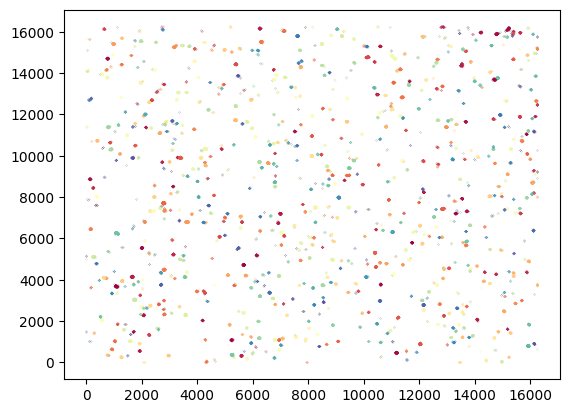

In [4]:
exp_data.plot_cluster()

### Detailed view

59868
[0.00000000e+00 5.00008352e-03 1.00001670e-02 ... 2.99330000e+02
 2.99335000e+02 2.99340000e+02]
299.34000000000003


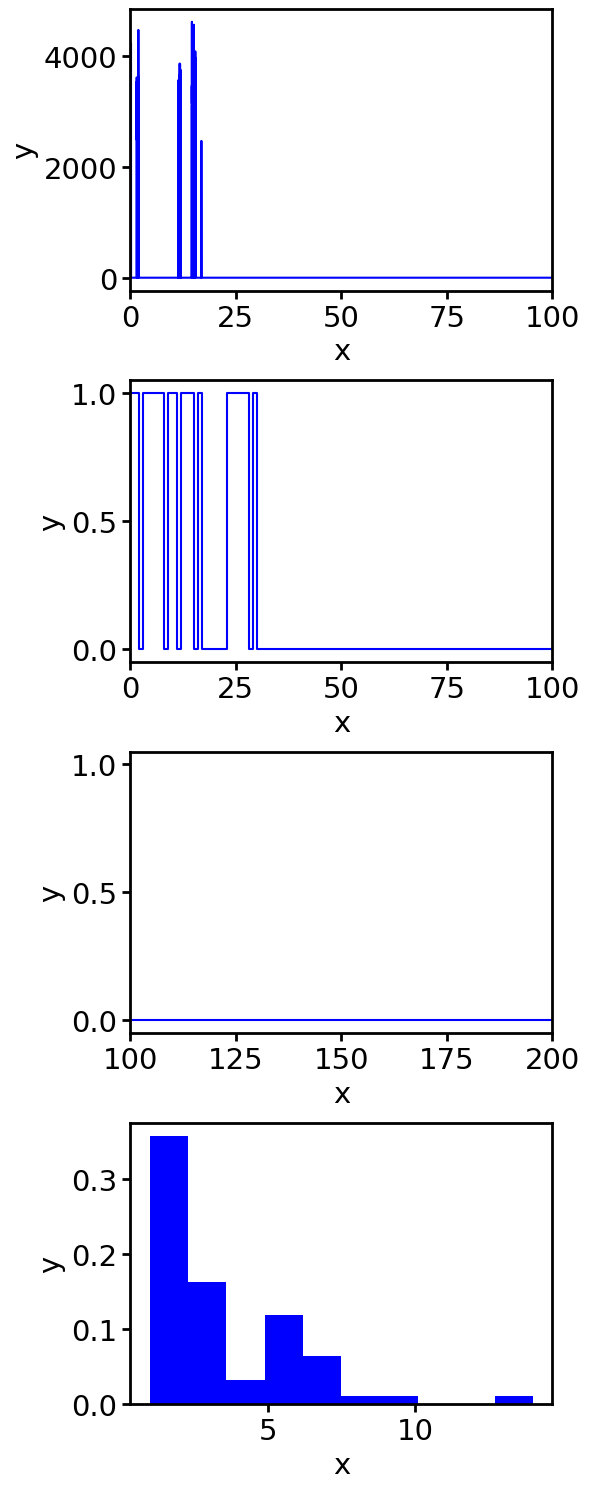

In [11]:
event_time_series = exp_data.get_event_time_series(4, '5ms')
on_periods, off_periods, on_frames, off_frames = bl.get_blinking_statistics(event_time_series)
on_off_frames, on_off_values = bl.get_analytical_off_statistics(off_frames, off_periods)

# plot it
axes = fi.universal_figure(nrows=4, fig_height=15)
fi.universal_figure(axes=axes[0], type_='line', data=[event_time_series.index, event_time_series.values], xlim=[0, 100])
fi.universal_figure(axes=axes[1], type_='line', data=[on_off_frames, on_off_values], xlim=[0, 100])
fi.universal_figure(axes=axes[2], type_='line', data=[on_off_frames, on_off_values], xlim=[100, 200])
fi.universal_figure(axes=axes[3], type_='hist', data=on_periods, density=True)
fig = mi.get_figure(axes)
fig.tight_layout()
        

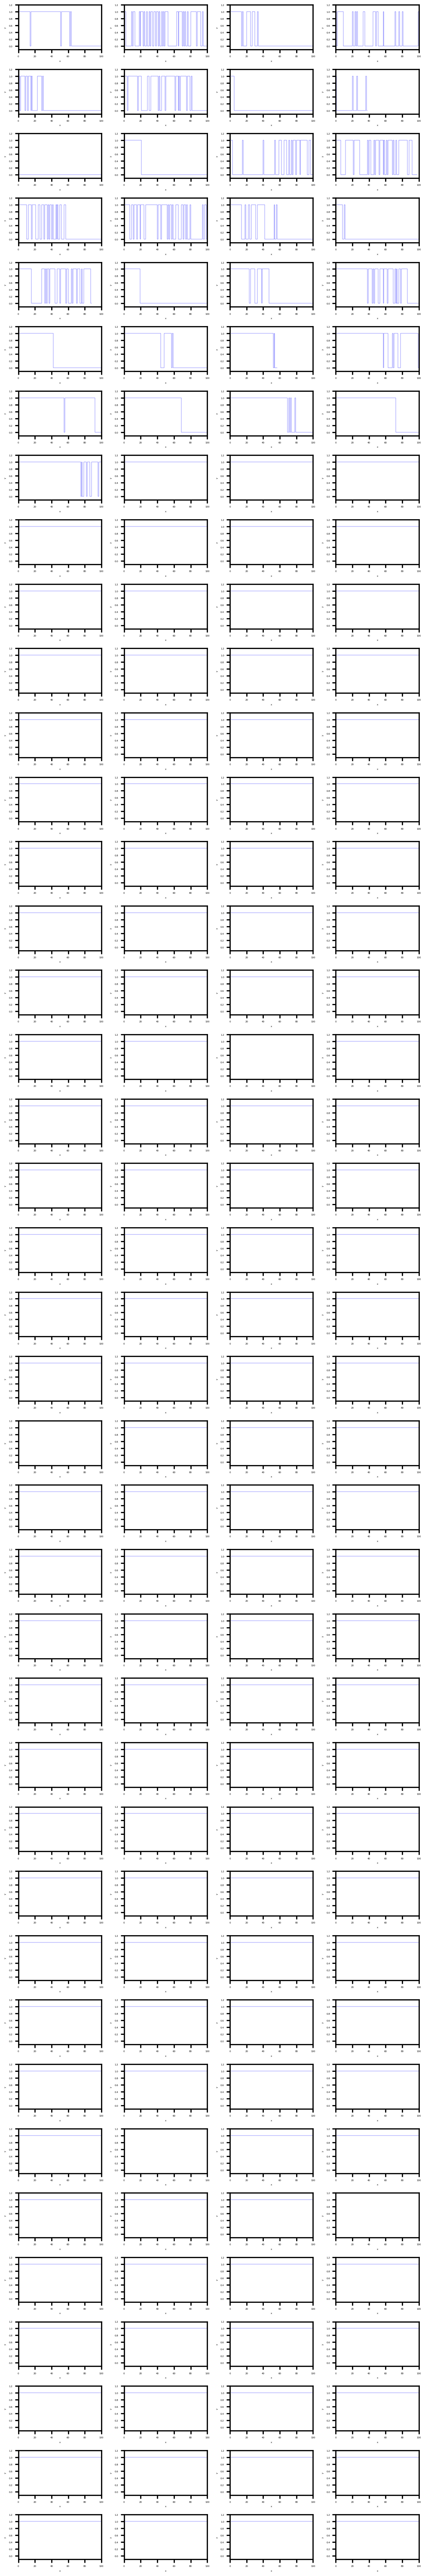

In [14]:
nrows = 40
ncols = 4


axes = fi.universal_figure(nrows=nrows, ncols=ncols, fig_height=nrows*1.5, fig_width=10)
j = 0
h = 0
for i in np.arange(0, nrows*ncols, 1):
    if j > ncols-1:
        h += 1
        j = 0
    event_time_series = exp_data.get_event_time_series(i)
    on_periods, off_periods, on_frames, off_frames = bl.get_blinking_statistics(event_time_series)
    on_off_frames, on_off_values = bl.get_analytical_off_statistics(off_frames, off_periods)
    # fi.universal_figure(axes=axes[h, j], type_='line', data=[event_time_series.index, event_time_series.values], 
    #                     xlim=[0, 100], fontsize=4, lw=0.3)
    fi.universal_figure(axes=axes[h, j], type_='line', data=[on_off_frames, on_off_values], xlim=[0, 100],
                        fontsize=4, lw=0.3, ylim=[-0.1, 1.2])
    j += 1
fig = mi.get_figure(axes)
fig.tight_layout()